In [70]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

VALID_EMOTIONS = sorted({"anger", "boredom", "anxiety", "happiness", "sadness", "disgust", "neutral"})

EMOTION_MAP = {
    'W': 'anger',
    'L': 'boredom',
    'E': 'disgust',
    'A': 'anxiety',  # German "Angst" = fear/anxiety
    'F': 'happiness',
    'T': 'sadness',
    'N': 'neutral',
}

# Normalize model output labels to match ground truth
# "fear" and "anxiety" are the same class (EMO-DB label A = Angst)
LABEL_ALIASES = {
    "fear":  "anxiety",
    "angry": "anger",
}

def normalize(label):
    """Lowercase and apply aliases (e.g. fear → anxiety)."""
    label = label.strip().lower()
    return LABEL_ALIASES.get(label, label)

MODELS = {
    "MERaLiON (default prompt)":  "emotion_results.json",
    "Qwen2-Audio-7B (default prompt)": "emotion_results_qwen_normal.json",
    "Flamingo-3 (default prompt)": "emotion_results_audioflamingo_normal.json",
}

# Load results for each model
all_results = {}
for model_name, results_file in MODELS.items():
    p = Path(results_file)
    if p.exists():
        with open(p) as f:
            all_results[model_name] = json.load(f)
        print(f"[OK] {model_name}: {len(all_results[model_name])} files loaded from {results_file}")
    else:
        print(f"[--] {model_name}: {results_file} not found — run classify script first")

[OK] MERaLiON (default prompt): 535 files loaded from emotion_results.json
[OK] Qwen2-Audio-7B (default prompt): 535 files loaded from emotion_results_qwen_normal.json
[OK] Flamingo-3 (default prompt): 535 files loaded from emotion_results_audioflamingo_normal.json


In [71]:
# Extract ground truth from filenames
wav_dir = Path("wav")
ground_truth = {}
for f in sorted(wav_dir.glob("*.wav")):
    code = Path(f.name).stem[5] if len(Path(f.name).stem) >= 6 else None
    if code in EMOTION_MAP:
        ground_truth[f.name] = EMOTION_MAP[code]

print(f"Ground truth: {len(ground_truth)} files\n")

# Show valid/invalid label breakdown per model (after normalization)
for model_name, results in all_results.items():
    invalid = {fn: v for fn, v in results.items()
               if normalize(v) not in VALID_EMOTIONS}
    print(f"{model_name}")
    print(f"  Valid (after normalization): {len(results) - len(invalid)} / {len(results)}")
    print(f"  Still invalid: {len(invalid)}")
    if invalid:
        for label, count in Counter(invalid.values()).most_common():
            print(f"    '{label}': {count}")
    print()

Ground truth: 535 files

MERaLiON (default prompt)
  Valid (after normalization): 520 / 535
  Still invalid: 15
    'curiosity': 9
    'surprise': 5
    'confusion': 1

Qwen2-Audio-7B (default prompt)
  Valid (after normalization): 416 / 535
  Still invalid: 119
    'Fearful': 80
    'Happy': 31
    'happy': 5
    'Sad': 3

Flamingo-3 (default prompt)
  Valid (after normalization): 384 / 535
  Still invalid: 151
    'happy': 68
    'sad': 55
    'disgusted': 27
    'sleepy': 1



In [72]:
def evaluate(results, ground_truth):
    y_true, y_pred = [], []
    for filename, true_label in ground_truth.items():
        pred = normalize(results.get(filename, ""))
        if pred in VALID_EMOTIONS:
            y_true.append(true_label)
            y_pred.append(pred)
    return y_true, y_pred

for model_name, results in all_results.items():
    y_true, y_pred = evaluate(results, ground_truth)
    print(f"{'=' * 70}")
    print(f"{model_name}  ({len(y_true)} files evaluated)")
    print(f"{'=' * 70}")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.2%}\n")
    print(classification_report(y_true, y_pred, labels=VALID_EMOTIONS, zero_division=0))
    print()

MERaLiON (default prompt)  (520 files evaluated)
Accuracy: 46.15%

              precision    recall  f1-score   support

       anger       0.97      0.48      0.64       126
     anxiety       0.72      0.39      0.51        66
     boredom       0.00      0.00      0.00        79
     disgust       0.00      0.00      0.00        42
   happiness       0.36      0.61      0.45        66
     neutral       0.36      0.89      0.51        79
     sadness       0.38      0.71      0.49        62

    accuracy                           0.46       520
   macro avg       0.40      0.44      0.37       520
weighted avg       0.47      0.46      0.41       520


Qwen2-Audio-7B (default prompt)  (416 files evaluated)
Accuracy: 71.39%

              precision    recall  f1-score   support

       anger       0.77      1.00      0.87       127
     anxiety       0.90      0.90      0.90        10
     boredom       1.00      0.03      0.05        76
     disgust       0.97      0.72      0.83  

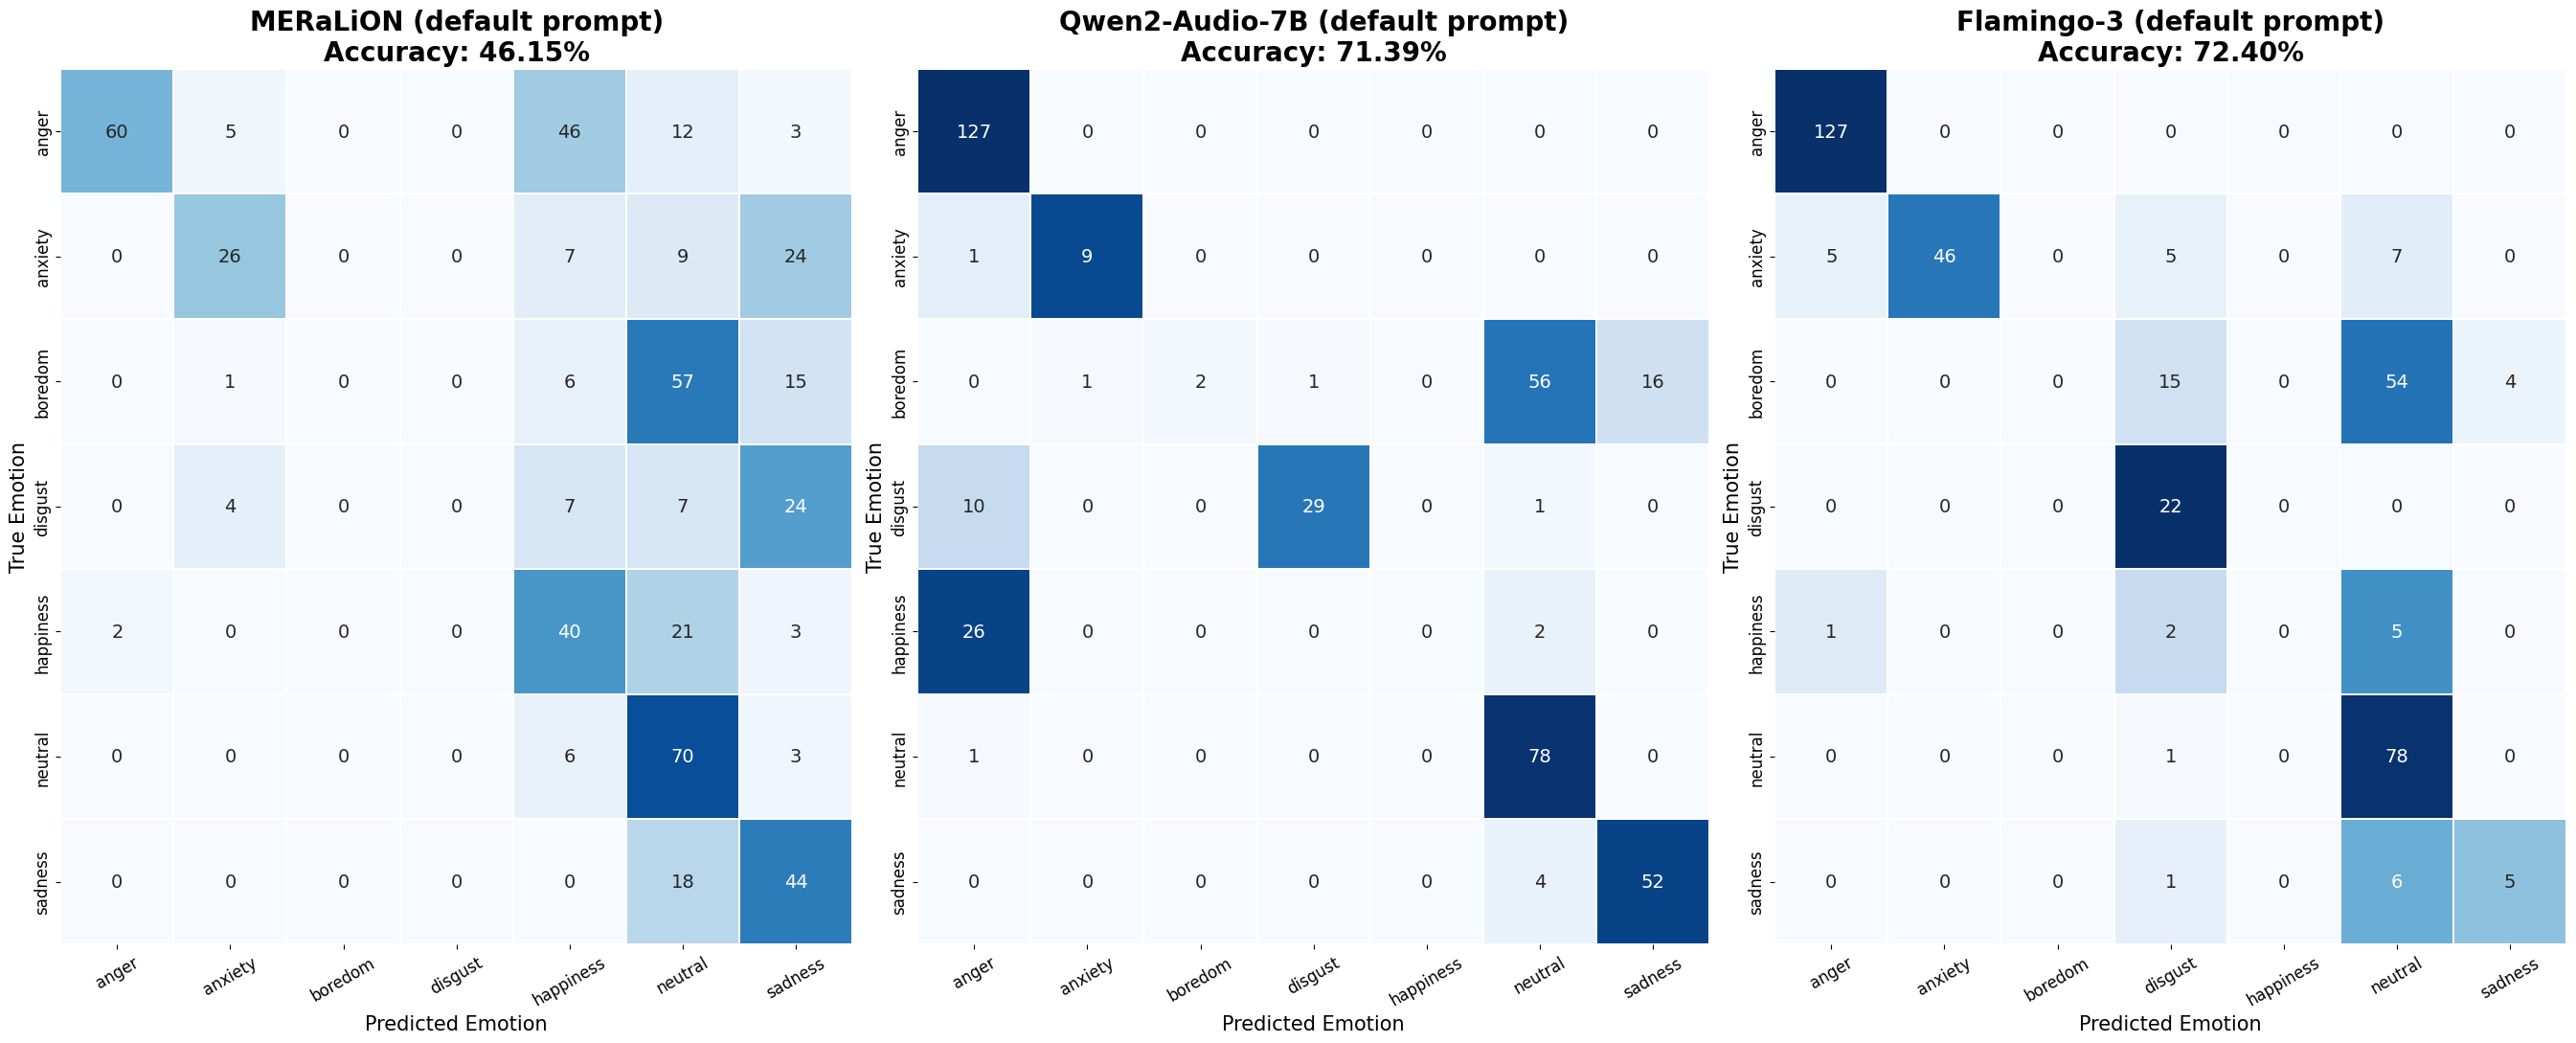

In [73]:
n = len(all_results)
fig, axes = plt.subplots(1, n, figsize=(9 * n, 11))
if n == 1:
    axes = [axes]

for ax, (model_name, results) in zip(axes, all_results.items()):
    y_true, y_pred = evaluate(results, ground_truth)
    cm = confusion_matrix(y_true, y_pred, labels=VALID_EMOTIONS)

    # Normalise rows for colour, annotate with raw counts
    cm_norm = cm.astype(float)
    row_sums = cm_norm.sum(axis=1, keepdims=True)
    cm_norm = np.where(row_sums == 0, 0, cm_norm / row_sums)

    sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues',
                vmin=0, vmax=1,
                xticklabels=VALID_EMOTIONS,
                yticklabels=VALID_EMOTIONS,
                cbar=False, ax=ax, linewidths=0.3,
                annot_kws={"size": 14})

    acc = accuracy_score(y_true, y_pred)
    ax.set_title(f"{model_name}\nAccuracy: {acc:.2%}", fontsize=20, fontweight='bold')
    ax.set_xlabel('Predicted Emotion', fontsize=15)
    ax.set_ylabel('True Emotion', fontsize=15)
    ax.tick_params(axis='x', rotation=30, labelsize=12)
    ax.tick_params(axis='y', labelsize=12)

plt.tight_layout()
plt.show()

### Gender Bias Analysis
EmoDB speaker IDs are encoded in the first two characters of each filename. We split predictions by gender and compare accuracy and per-class performance.

In [74]:
GENDER_MAP = {
    '03': 'male', '10': 'male', '11': 'male', '12': 'male', '15': 'male',
    '08': 'female', '09': 'female', '13': 'female', '14': 'female', '16': 'female',
}

def get_gender(filename):
    return GENDER_MAP.get(filename[:2], 'unknown')

def evaluate_gender_bias(results, ground_truth, model_name):
    y_true_m, y_pred_m = [], []
    y_true_f, y_pred_f = [], []

    for filename, true_label in ground_truth.items():
        pred = normalize(results.get(filename, ""))
        if pred not in VALID_EMOTIONS:
            continue
        gender = get_gender(filename)
        if gender == 'male':
            y_true_m.append(true_label)
            y_pred_m.append(pred)
        elif gender == 'female':
            y_true_f.append(true_label)
            y_pred_f.append(pred)

    print(f"\n{'='*60}")
    print(f"Gender Bias Analysis: {model_name}")
    print(f"{'='*60}")
    for gender, y_true, y_pred in [('Male', y_true_m, y_pred_m), ('Female', y_true_f, y_pred_f)]:
        acc = accuracy_score(y_true, y_pred)
        print(f"\n--- {gender} ({len(y_true)} samples) ---")
        print(f"Accuracy: {acc:.2%}")
        print(classification_report(y_true, y_pred, labels=VALID_EMOTIONS, zero_division=0))

    acc_m = accuracy_score(y_true_m, y_pred_m)
    acc_f = accuracy_score(y_true_f, y_pred_f)
    print(f"Accuracy gap (Female - Male): {acc_f - acc_m:+.2%}")
    return acc_m, acc_f

gender_accs = {}
for model_name, results in all_results.items():
    gender_accs[model_name] = evaluate_gender_bias(results, ground_truth, model_name)


Gender Bias Analysis: MERaLiON (default prompt)

--- Male (225 samples) ---
Accuracy: 44.89%
              precision    recall  f1-score   support

       anger       1.00      0.53      0.69        59
     anxiety       0.75      0.35      0.48        34
     boredom       0.00      0.00      0.00        34
     disgust       0.00      0.00      0.00         9
   happiness       0.33      0.52      0.41        25
     neutral       0.34      0.92      0.49        39
     sadness       0.28      0.36      0.32        25

    accuracy                           0.45       225
   macro avg       0.39      0.38      0.34       225
weighted avg       0.50      0.45      0.42       225


--- Female (295 samples) ---
Accuracy: 47.12%
              precision    recall  f1-score   support

       anger       0.94      0.43      0.59        67
     anxiety       0.70      0.44      0.54        32
     boredom       0.00      0.00      0.00        45
     disgust       0.00      0.00      0.00  

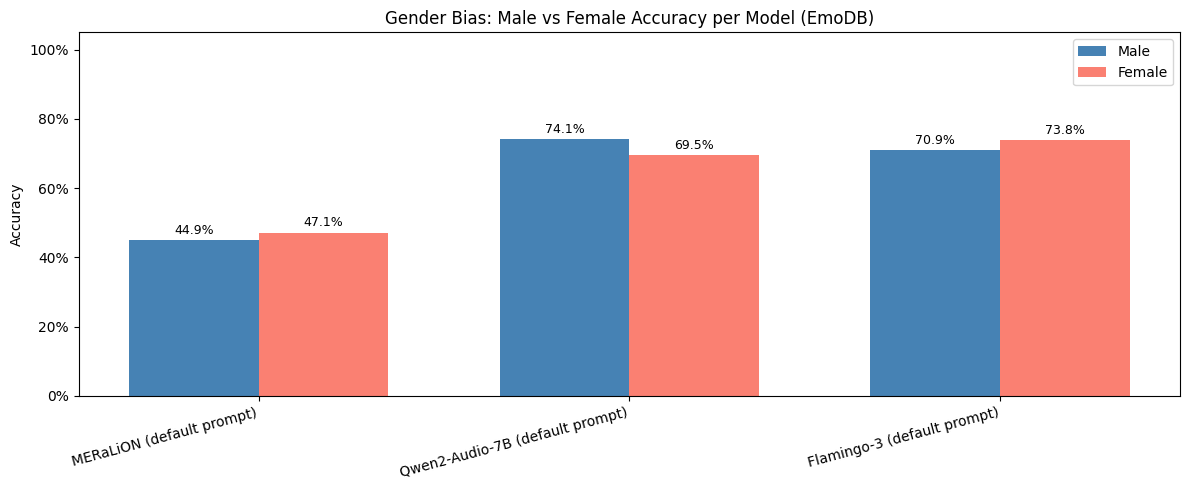

In [75]:
model_labels = list(gender_accs.keys())
male_accs   = [gender_accs[m][0] for m in model_labels]
female_accs = [gender_accs[m][1] for m in model_labels]

x = np.arange(len(model_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars_m = ax.bar(x - width/2, male_accs,   width, label='Male',   color='steelblue')
bars_f = ax.bar(x + width/2, female_accs, width, label='Female', color='salmon')

ax.set_ylabel('Accuracy')
ax.set_title('Gender Bias: Male vs Female Accuracy per Model (EmoDB)')
ax.set_xticks(x)
ax.set_xticklabels(model_labels, rotation=15, ha='right')
ax.set_ylim(0, 1.05)
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))

for bar in bars_m:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.1%}', ha='center', va='bottom', fontsize=9)
for bar in bars_f:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.1%}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

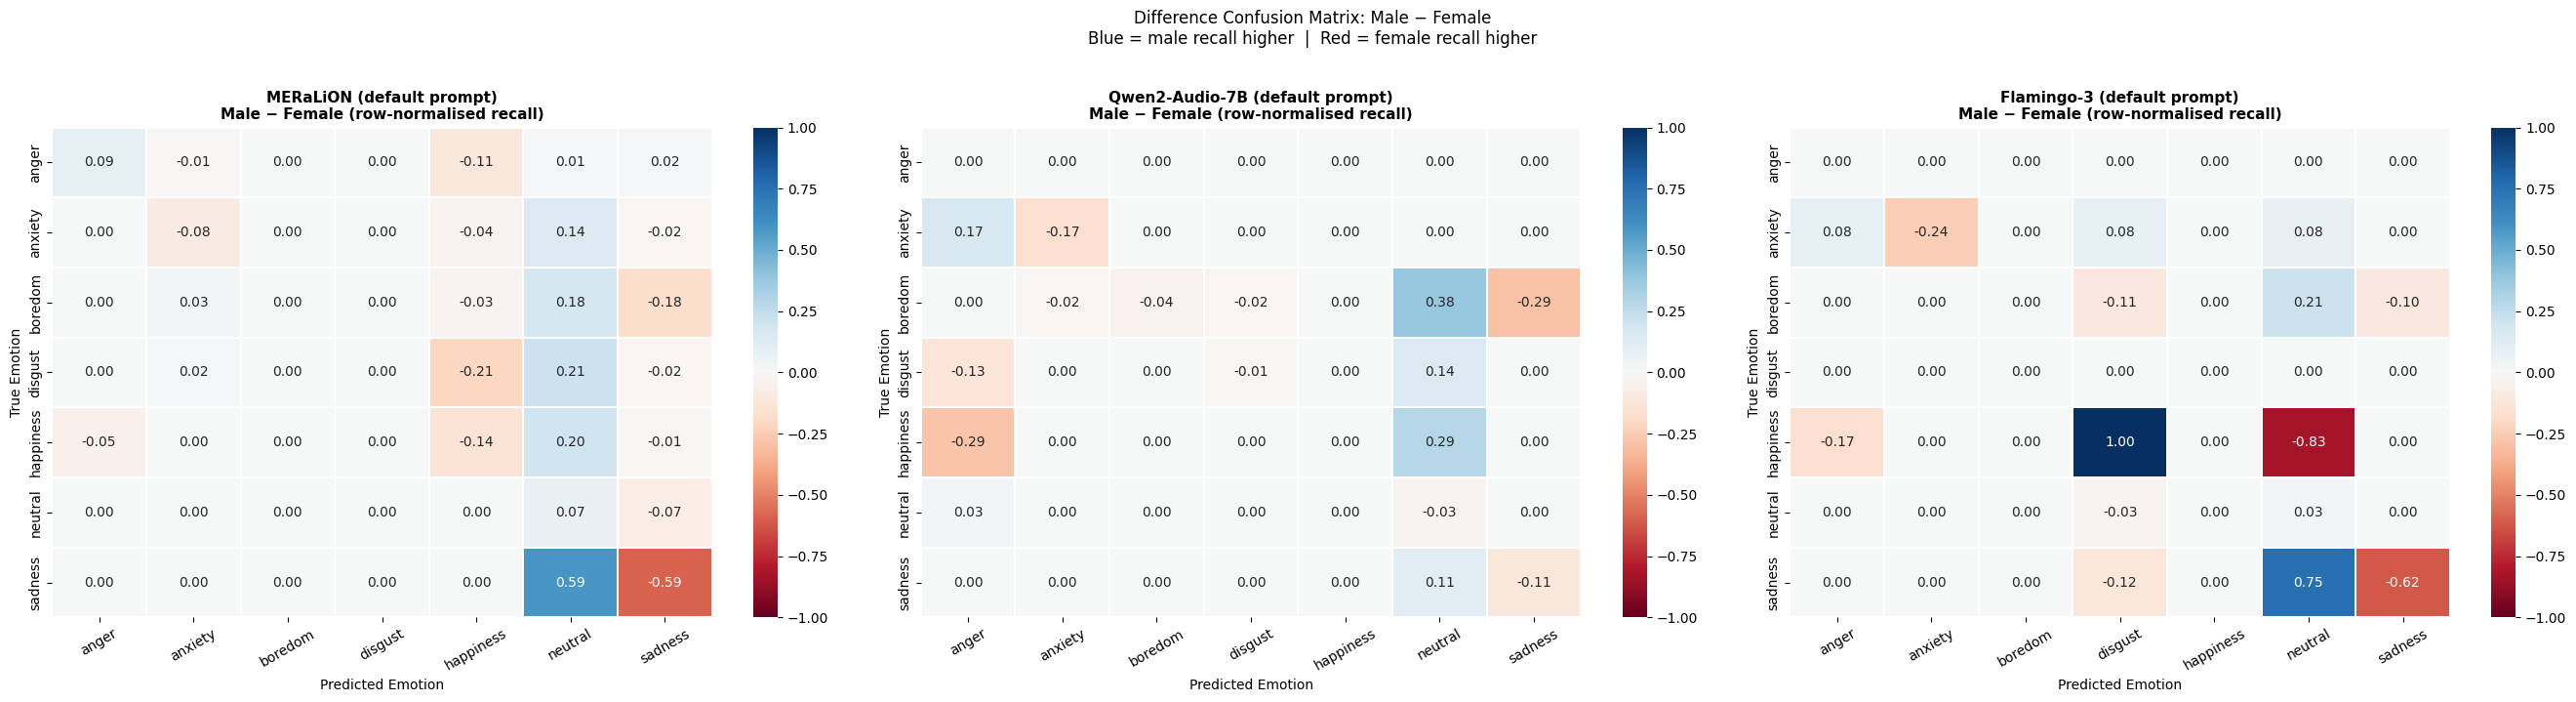

In [76]:
def plot_diff_confusion_matrix(results, ground_truth, model_name, ax):
    y_true_m, y_pred_m = [], []
    y_true_f, y_pred_f = [], []

    for filename, true_label in ground_truth.items():
        pred = normalize(results.get(filename, ""))
        if pred not in VALID_EMOTIONS:
            continue
        gender = get_gender(filename)
        if gender == 'male':
            y_true_m.append(true_label)
            y_pred_m.append(pred)
        elif gender == 'female':
            y_true_f.append(true_label)
            y_pred_f.append(pred)

    cm_m = confusion_matrix(y_true_m, y_pred_m, labels=VALID_EMOTIONS).astype(float)
    cm_f = confusion_matrix(y_true_f, y_pred_f, labels=VALID_EMOTIONS).astype(float)

    # Row-normalize (recall per class), then subtract
    cm_m_norm = cm_m / cm_m.sum(axis=1, keepdims=True).clip(min=1)
    cm_f_norm = cm_f / cm_f.sum(axis=1, keepdims=True).clip(min=1)
    diff = cm_m_norm - cm_f_norm

    sns.heatmap(diff, annot=True, fmt='.2f', cmap='RdBu', center=0,
                vmin=-1, vmax=1,
                xticklabels=VALID_EMOTIONS, yticklabels=VALID_EMOTIONS,
                cbar=True, ax=ax, linewidths=0.3)
    ax.set_title(f"{model_name}\nMale − Female (row-normalised recall)", fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted Emotion')
    ax.set_ylabel('True Emotion')
    ax.tick_params(axis='x', rotation=30)

n = len(all_results)
fig, axes = plt.subplots(1, n, figsize=(9 * n, 7))
if n == 1:
    axes = [axes]

for ax, (model_name, results) in zip(axes, all_results.items()):
    plot_diff_confusion_matrix(results, ground_truth, model_name, ax)

plt.suptitle('Difference Confusion Matrix: Male − Female\nBlue = male recall higher  |  Red = female recall higher',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### Zusätzliche Bias-Analysen
Drei weitere Auswertungen, die über den groben M-vs-F-Accuracy-Vergleich hinausgehen:

1. **Compliance-Bias** — Verweigert das Modell bei einem Geschlecht öfter ein parsbares Label?
2. **Bootstrap-CI** — Ist der gemessene Accuracy-Gap statistisch real?
3. **Sprecher-Varianz** — Ist der Gap durch wenige Einzelsprecher getrieben?

In [77]:
# === Bias-Analyse 1: Invalid-Output-Rate je Geschlecht (Compliance-Bias) ===
# Frage: Verweigert das Modell bei einem Geschlecht oeftner ein parsbares Label?
import pandas as pd

invalid_rows = []
for model_name, results in all_results.items():
    n_m = inv_m = n_f = inv_f = 0
    for filename in ground_truth.keys():
        if filename not in results:
            continue
        g = get_gender(filename)
        if g == 'male':
            n_m += 1
            if normalize(results[filename]) not in VALID_EMOTIONS:
                inv_m += 1
        elif g == 'female':
            n_f += 1
            if normalize(results[filename]) not in VALID_EMOTIONS:
                inv_f += 1
    rate_m = inv_m / n_m if n_m else 0
    rate_f = inv_f / n_f if n_f else 0
    invalid_rows.append({
        'Model':       model_name,
        'M total':     n_m,
        'M invalid':   inv_m,
        'M rate':      f'{rate_m:.1%}',
        'F total':     n_f,
        'F invalid':   inv_f,
        'F rate':      f'{rate_f:.1%}',
        'Gap (M-F)':   f'{(rate_m - rate_f)*100:+.1f} pp',
    })

print("Invalid-Output-Rate je Geschlecht (Compliance-Bias)\n")
print(pd.DataFrame(invalid_rows).to_string(index=False))


Invalid-Output-Rate je Geschlecht (Compliance-Bias)

                          Model  M total  M invalid M rate  F total  F invalid F rate Gap (M-F)
      MERaLiON (default prompt)      233          8   3.4%      302          7   2.3%   +1.1 pp
Qwen2-Audio-7B (default prompt)      233         63  27.0%      302         56  18.5%   +8.5 pp
    Flamingo-3 (default prompt)      233         51  21.9%      302        100  33.1%  -11.2 pp


In [78]:
# === Bias-Analyse 2: Bootstrap-95%-CI auf den Accuracy-Gap ===
# Frage: Ist der Gender-Gap statistisch real oder Sampling-Rauschen?
# 1000 Resamples mit Wiederlegung pro Geschlecht; CI durch Perzentile.
import pandas as pd

N_BOOTSTRAP = 1000
rng = np.random.default_rng(42)

ci_rows = []
for model_name, results in all_results.items():
    correct_m, correct_f = [], []
    for filename, true_label in ground_truth.items():
        pred = normalize(results.get(filename, ""))
        if pred not in VALID_EMOTIONS:
            continue
        g = get_gender(filename)
        if g == 'male':
            correct_m.append(pred == true_label)
        elif g == 'female':
            correct_f.append(pred == true_label)

    arr_m = np.array(correct_m, dtype=bool)
    arr_f = np.array(correct_f, dtype=bool)
    acc_m, acc_f = arr_m.mean(), arr_f.mean()
    gap = acc_f - acc_m

    gaps = np.empty(N_BOOTSTRAP)
    for i in range(N_BOOTSTRAP):
        gaps[i] = rng.choice(arr_f, size=len(arr_f), replace=True).mean() - \
                  rng.choice(arr_m, size=len(arr_m), replace=True).mean()
    ci_low, ci_high = np.percentile(gaps, [2.5, 97.5])
    is_sig = (ci_low > 0) or (ci_high < 0)

    ci_rows.append({
        'Model': model_name,
        'N (M/F)': f'{len(arr_m)}/{len(arr_f)}',
        'Acc M': f'{acc_m:.1%}',
        'Acc F': f'{acc_f:.1%}',
        'Gap (F-M)': f'{gap*100:+.2f} pp',
        '95% CI': f'[{ci_low*100:+.2f}, {ci_high*100:+.2f}] pp',
        'Significant?': 'yes' if is_sig else 'no',
    })

print("Bootstrap 95%-CI auf den Female-Male Accuracy-Gap (n=1000)\n")
print(pd.DataFrame(ci_rows).to_string(index=False))


Bootstrap 95%-CI auf den Female-Male Accuracy-Gap (n=1000)

                          Model N (M/F) Acc M Acc F Gap (F-M)             95% CI Significant?
      MERaLiON (default prompt) 225/295 44.9% 47.1%  +2.23 pp [-6.67, +11.14] pp           no
Qwen2-Audio-7B (default prompt) 170/246 74.1% 69.5%  -4.61 pp [-13.42, +3.54] pp           no
    Flamingo-3 (default prompt) 182/202 70.9% 73.8%  +2.88 pp [-6.25, +11.57] pp           no


In [79]:
# === Bias-Analyse 3: Per-Sprecher-Accuracy ===
# Frage: Ist der Gender-Gap durch wenige Sprecher getrieben oder gleichmaessig
# verteilt? EmoDB hat nur 10 Sprecher (5 M / 5 F), entsprechend hohe Varianz
# moeglich.
from collections import defaultdict

male_ids   = ['03', '10', '11', '12', '15']
female_ids = ['08', '09', '13', '14', '16']

print("Per-Sprecher-Accuracy (EmoDB: 5 M / 5 F)\n")
for model_name, results in all_results.items():
    sp_correct = defaultdict(lambda: [0, 0])  # [correct, total]
    for filename, true_label in ground_truth.items():
        pred = normalize(results.get(filename, ""))
        if pred not in VALID_EMOTIONS:
            continue
        sp = filename[:2]
        sp_correct[sp][1] += 1
        if pred == true_label:
            sp_correct[sp][0] += 1

    m_accs = [sp_correct[s][0] / sp_correct[s][1] for s in male_ids   if sp_correct[s][1] > 0]
    f_accs = [sp_correct[s][0] / sp_correct[s][1] for s in female_ids if sp_correct[s][1] > 0]

    print(f"--- {model_name} ---")
    print("  Male   : " + "  ".join(f"{s}={sp_correct[s][0]/sp_correct[s][1]:.1%}" for s in male_ids))
    print("  Female : " + "  ".join(f"{s}={sp_correct[s][0]/sp_correct[s][1]:.1%}" for s in female_ids))
    if m_accs and f_accs:
        m_range = max(m_accs) - min(m_accs)
        f_range = max(f_accs) - min(f_accs)
        gap_mean = np.mean(f_accs) - np.mean(m_accs)
        print(f"  Male   mean={np.mean(m_accs):.1%}  std={np.std(m_accs):.1%}  range={m_range*100:.1f} pp")
        print(f"  Female mean={np.mean(f_accs):.1%}  std={np.std(f_accs):.1%}  range={f_range*100:.1f} pp")
        print(f"  Sprecher-gemittelter Gap (F-M): {gap_mean*100:+.1f} pp")
        if abs(gap_mean) < max(m_range, f_range) / 2:
            print(f"  HINWEIS: Gap ist klein gegenueber Sprecher-Varianz - wahrscheinlich von Einzelsprechern getrieben.")
    print()


Per-Sprecher-Accuracy (EmoDB: 5 M / 5 F)

--- MERaLiON (default prompt) ---
  Male   : 03=50.0%  10=43.2%  11=42.3%  12=38.2%  15=48.1%
  Female : 08=58.9%  09=48.8%  13=48.3%  14=41.8%  16=40.6%
  Male   mean=44.4%  std=4.2%  range=11.8 pp
  Female mean=47.7%  std=6.5%  range=18.3 pp
  Sprecher-gemittelter Gap (F-M): +3.3 pp
  HINWEIS: Gap ist klein gegenueber Sprecher-Varianz - wahrscheinlich von Einzelsprechern getrieben.

--- Qwen2-Audio-7B (default prompt) ---
  Male   : 03=77.5%  10=72.0%  11=72.2%  12=71.4%  15=75.6%
  Female : 08=66.7%  09=80.0%  13=65.2%  14=75.0%  16=62.5%
  Male   mean=73.8%  std=2.4%  range=6.1 pp
  Female mean=69.9%  std=6.6%  range=17.5 pp
  Sprecher-gemittelter Gap (F-M): -3.9 pp
  HINWEIS: Gap ist klein gegenueber Sprecher-Varianz - wahrscheinlich von Einzelsprechern getrieben.

--- Flamingo-3 (default prompt) ---
  Male   : 03=76.9%  10=71.0%  11=67.5%  12=65.5%  15=72.1%
  Female : 08=66.7%  09=82.8%  13=71.7%  14=76.6%  16=73.2%
  Male   mean=70.6%  